In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/laveshjadon/ai-impact-on-students/ai_student_impact_dataset (1).csv")

In [3]:
df.head(20)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [4]:
b=df[["Major_Category","Paid_Subscription"]].value_counts().reset_index()
b

,Major_Category,Paid_Subscription,count
0,STEM,False,8175
1,Business,False,7304
2,STEM,True,6884
3,Humanities,False,6007
4,Business,True,5234
5,Humanities,True,3987
6,Medical,False,3860
7,Arts,False,3500
8,Medical,True,2616
9,Arts,True,2433


Graph showing the subscription of AI models per Major Categores.

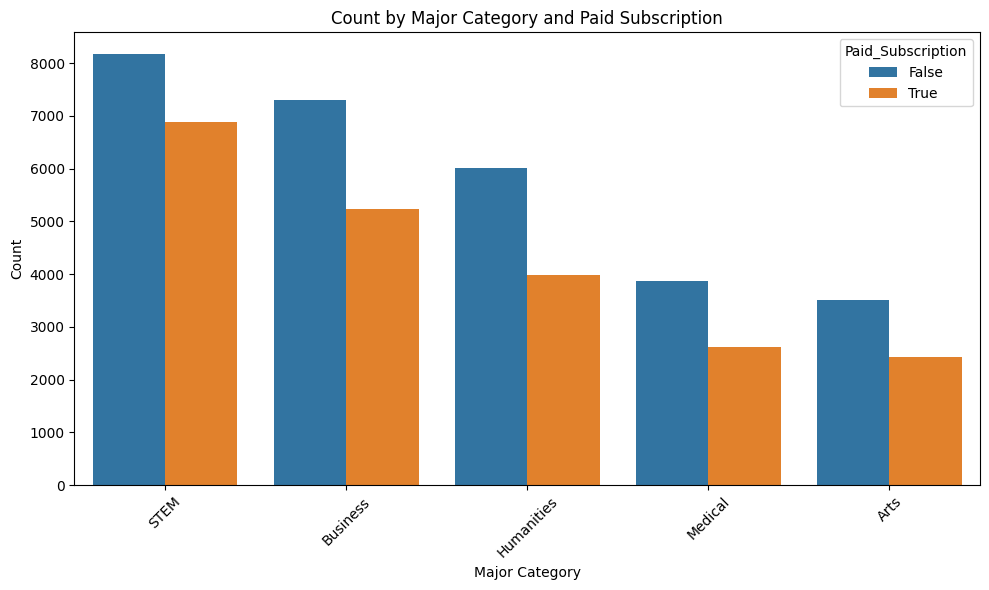

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=b, x='Major_Category', y='count', hue='Paid_Subscription')
plt.title('Count by Major Category and Paid Subscription')
plt.xlabel('Major Category')
plt.ylabel('Count')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

In [6]:
Stem=df.loc[df['Major_Category'] == 'STEM']
a=Stem["Primary_Use_Case"].value_counts().reset_index()
a

,Primary_Use_Case,count
0,Debugging/Troubleshooting,7793
1,Direct_Answer_Generation,1863
2,Copywriting/Drafting,1815
3,Summarizing_Reading,1798
4,Ideation,1790


Graph showing the use case of AI models by Stem Students.

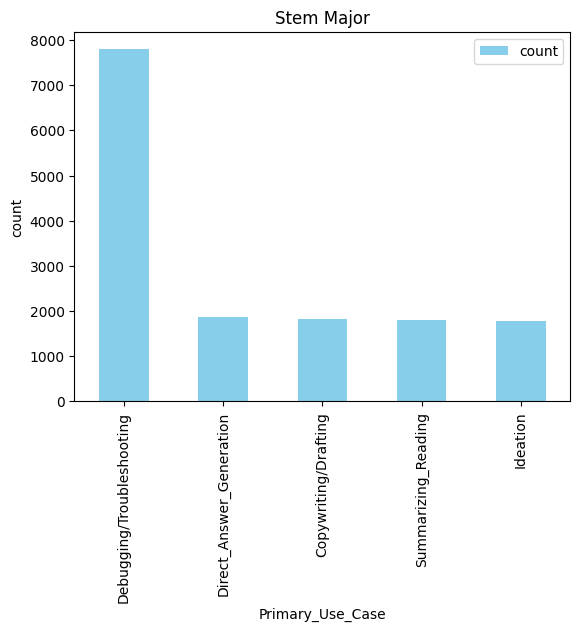

In [7]:

a.plot(kind='bar', x='Primary_Use_Case', y='count', color='skyblue')

plt.title('Stem Major')
plt.ylabel('count')
plt.show()

In [8]:
grouped=df.groupby("Major_Category")[["Weekly_GenAI_Hours","Tool_Diversity"]].mean()
grouped

,Weekly_GenAI_Hours,Tool_Diversity
Major_Category,,
Arts,7.271702,2.762683
Business,8.275898,2.740788
Humanities,6.770144,2.744347
Medical,7.546728,2.767295
STEM,10.488609,2.915864


Graph showing the relationship between "Weekly Usage" and the "Tool Diversity"

/tmp/ipykernel_16/3872408812.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (grouped['Weekly_GenAI_Hours'][i], grouped['Tool_Diversity'][i]))


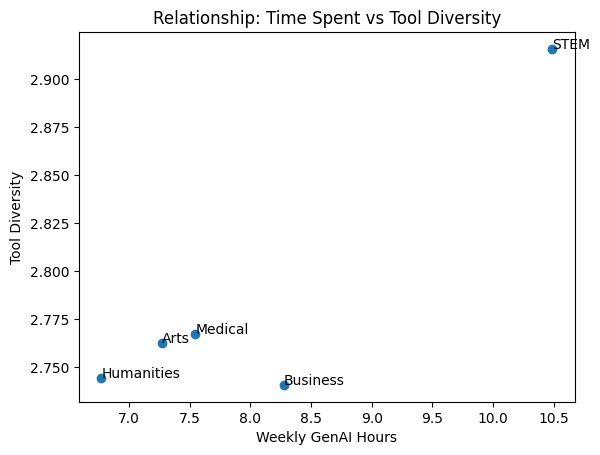

In [9]:
plt.scatter(grouped['Weekly_GenAI_Hours'], grouped['Tool_Diversity'])
for i, txt in enumerate(grouped.index):
    plt.annotate(txt, (grouped['Weekly_GenAI_Hours'][i], grouped['Tool_Diversity'][i]))

plt.xlabel('Weekly GenAI Hours')
plt.ylabel('Tool Diversity')
plt.title('Relationship: Time Spent vs Tool Diversity')
plt.show()